# Chapter 9: Next-GW Prediction — Model v4

The v3 model predicts 'good players overall' rather than 'who will score next GW.'
This notebook adds:
1. **Opponent strength features** — who the player faces NEXT
2. **EMA rolling averages** — recency-weighted form
3. **Last-1-GW raw features** — single-game standout detection
4. **Form acceleration** — hot streak / trend signals
5. **Bias correction** — remove ownership bias, add pts_per_price

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib, json

from src.fpl.predict import build_features, get_feature_columns

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

## 1. Build v4 Features

In [2]:
gw_df = build_features()
feature_cols = get_feature_columns()
print(f"Total rows: {len(gw_df):,}")
print(f"Feature columns: {len(feature_cols)}")

# Show new v4 feature samples
v4_new = ['next_opp_attack', 'next_opp_defence', 'next_fdr', 'is_home_next',
          'team_vs_opp', 'opp_strength_diff', 'pts_ema3', 'pts_ema5',
          'pts_last1', 'pts_accel_3v5', 'pts_spike', 'pts_per_price']
gw_df[v4_new].describe().round(3)

Total rows: 22,501
Feature columns: 101


,next_opp_attack,next_opp_defence,next_fdr,is_home_next,team_vs_opp,opp_strength_diff,pts_ema3,pts_ema5,pts_last1,pts_accel_3v5,pts_spike,pts_per_price
count,22501.000,22501.000,22501.000,22501.000,22501.000,22501.000,21681.000,21681.000,21681.000,21681.000,21681.000,21681.000
mean,-57.366,-6.881,3.047,0.499,-1.319,-50.485,1.188,1.193,1.181,-0.006,-0.015,0.222
std,83.939,88.823,0.866,0.500,124.512,66.007,1.869,1.744,2.378,0.669,1.655,0.345
min,-290.000,-200.000,1.000,0.000,-390.000,-180.000,-1.469,-1.200,-3.000,-6.067,-8.800,-0.263
25%,-100.000,-70.000,2.000,0.000,-80.000,-90.000,0.000,0.000,0.000,0.000,-0.250,0.000
50%,-60.000,-10.000,3.000,0.000,0.000,-60.000,0.078,0.207,0.000,0.000,0.000,0.000
75%,-30.000,60.000,4.000,1.000,80.000,0.000,1.871,2.000,1.000,0.000,0.000,0.354
max,190.000,200.000,5.000,1.000,390.000,80.000,17.000,17.000,24.000,4.867,17.400,3.696


## 2. Train/Test Split

In [3]:
train_mask = gw_df["round"].between(4, 22)
test_mask = gw_df["round"].between(23, 29)

train = gw_df[train_mask].dropna(subset=["target"]).copy()
test = gw_df[test_mask].dropna(subset=["target"]).copy()

X_train = train[feature_cols]
y_train = train["target"]
X_test = test[feature_cols]
y_test = test["target"]

print(f"Train: {len(X_train):,} rows (GW 4-22)")
print(f"Test:  {len(X_test):,} rows (GW 23-29)")

Train: 14,452 rows (GW 4-22)
Test:  5,942 rows (GW 23-29)


## 3. Hyperparameter Search

In [4]:
from itertools import product

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [300, 500, 800],
    'colsample_bytree': [0.6, 0.7, 0.8],
}

results = []
best_r2 = -999
best_model = None
best_params = None

combos = list(product(*param_grid.values()))
print(f"Testing {len(combos)} parameter combinations...")

for i, (md, lr, ne, cs) in enumerate(combos):
    model = XGBRegressor(
        max_depth=md, learning_rate=lr, n_estimators=ne,
        colsample_bytree=cs, subsample=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results.append({'max_depth': md, 'lr': lr, 'n_est': ne, 'colsample': cs,
                    'R2': r2, 'MAE': mae})
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_params = {'max_depth': md, 'lr': lr, 'n_est': ne, 'colsample': cs}
    if (i + 1) % 27 == 0:
        print(f"  {i+1}/{len(combos)} done — best R²={best_r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(f"\nBest params: {best_params}")
print(f"Best R²: {best_r2:.4f}")
results_df.head(10)

Testing 81 parameter combinations...


  27/81 done — best R²=0.3484


  54/81 done — best R²=0.3484


  81/81 done — best R²=0.3484

Best params: {'max_depth': 3, 'lr': 0.01, 'n_est': 500, 'colsample': 0.7}
Best R²: 0.3484


,max_depth,lr,n_est,colsample,R2,MAE
4,3,0.01,500,0.7,0.348415,0.949023
3,3,0.01,500,0.6,0.348331,0.949667
5,3,0.01,500,0.8,0.347387,0.951007
6,3,0.01,800,0.6,0.347004,0.947300
7,3,0.01,800,0.7,0.346875,0.946882
1,3,0.01,300,0.7,0.346097,0.966521
8,3,0.01,800,0.8,0.346075,0.948734
0,3,0.01,300,0.6,0.346069,0.966621
2,3,0.01,300,0.8,0.345426,0.968070
28,4,0.01,300,0.7,0.344983,0.971862


## 4. Ablation Study

In [5]:
# Define feature groups for ablation
feature_groups = {
    'opponent_strength': ['next_opp_attack', 'next_opp_defence', 'next_fdr',
                          'is_home_next', 'opp_strength_diff', 'team_vs_opp'],
    'ema_features': [f"{s}_ema{span}" for s in ['pts','xg','xa','xgi','bonus','bps','ict'] for span in [3,5]],
    'last1_features': ['pts_last1', 'xg_last1', 'xa_last1', 'bonus_last1', 'min_last1'],
    'form_acceleration': ['pts_accel_3v5', 'xg_accel_3v5', 'xgi_accel_3v5',
                          'pts_vs_season', 'xg_vs_season', 'pts_spike'],
    'bias_correction': ['pts_per_price'],
}

# Use best params for ablation
bp = best_params

# Full model baseline
full_model = XGBRegressor(
    max_depth=bp['max_depth'], learning_rate=bp['lr'],
    n_estimators=bp['n_est'], colsample_bytree=bp['colsample'],
    subsample=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
full_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
full_preds = full_model.predict(X_test)
full_r2 = r2_score(y_test, full_preds)
full_mae = mean_absolute_error(y_test, full_preds)
print(f"Full model (all v4 features): R²={full_r2:.4f}, MAE={full_mae:.3f}")
print()

# Ablation: remove each group
ablation_results = [{'group': 'FULL MODEL', 'R2': full_r2, 'MAE': full_mae, 'delta_R2': 0}]

for group_name, group_cols in feature_groups.items():
    reduced_cols = [c for c in feature_cols if c not in group_cols]
    m = XGBRegressor(
        max_depth=bp['max_depth'], learning_rate=bp['lr'],
        n_estimators=bp['n_est'], colsample_bytree=bp['colsample'],
        subsample=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1
    )
    m.fit(train[reduced_cols], y_train, eval_set=[(test[reduced_cols], y_test)], verbose=False)
    p = m.predict(test[reduced_cols])
    r2 = r2_score(y_test, p)
    mae = mean_absolute_error(y_test, p)
    delta = full_r2 - r2
    print(f"Without {group_name:25s}: R²={r2:.4f} (Δ={delta:+.4f}), MAE={mae:.3f}")
    ablation_results.append({'group': f'w/o {group_name}', 'R2': r2, 'MAE': mae, 'delta_R2': delta})

ablation_df = pd.DataFrame(ablation_results)
ablation_df

Full model (all v4 features): R²=0.3484, MAE=0.949



Without opponent_strength        : R²=0.3470 (Δ=+0.0014), MAE=0.950


Without ema_features             : R²=0.3478 (Δ=+0.0006), MAE=0.951


Without last1_features           : R²=0.3381 (Δ=+0.0103), MAE=0.957


Without form_acceleration        : R²=0.3468 (Δ=+0.0017), MAE=0.951


Without bias_correction          : R²=0.3471 (Δ=+0.0013), MAE=0.951


,group,R2,MAE,delta_R2
0,FULL MODEL,0.348415,0.949023,0.000000
1,w/o opponent_strength,0.346999,0.950262,0.001416
2,w/o ema_features,0.347775,0.951050,0.000640
3,w/o last1_features,0.338110,0.957497,0.010305
4,w/o form_acceleration,0.346763,0.951157,0.001653
5,w/o bias_correction,0.347086,0.950711,0.001330


## 5. Feature Importance (Top 30)

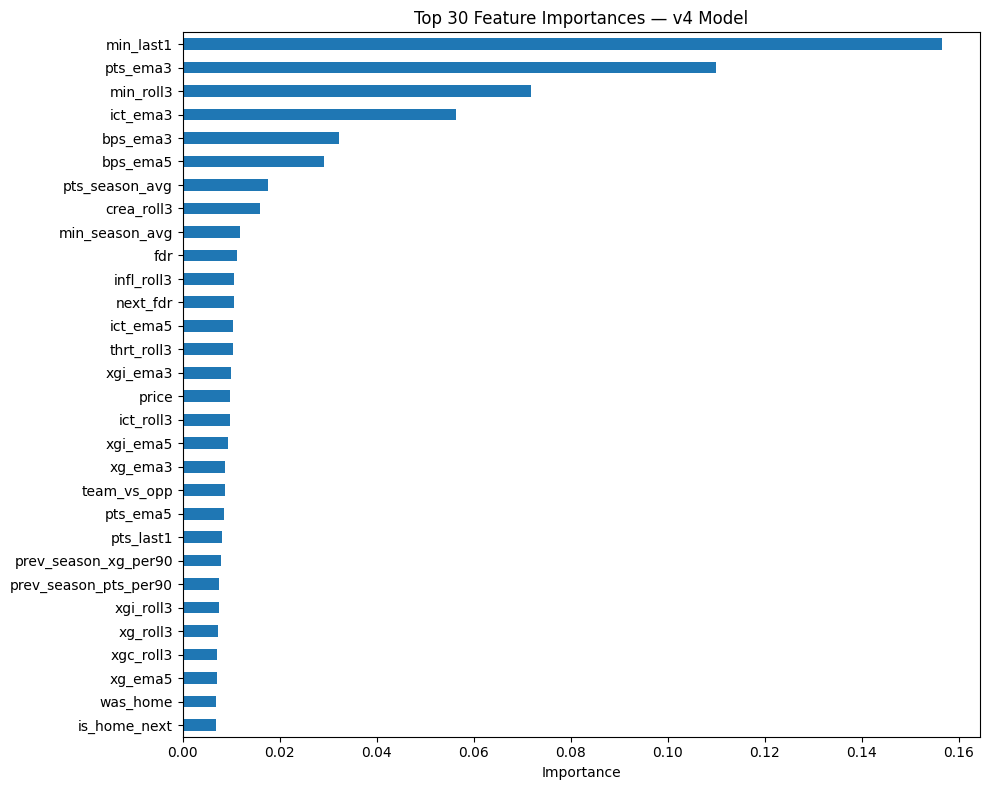

v4 features in top 20: ['min_last1', 'pts_ema3', 'ict_ema3', 'bps_ema3', 'bps_ema5', 'next_fdr', 'ict_ema5', 'xgi_ema3', 'xgi_ema5', 'xg_ema3', 'team_vs_opp']


In [6]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
top30 = importances.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importances — v4 Model')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Check if v4 features appear in top 20
v4_features = set()
for group_cols in feature_groups.values():
    v4_features.update(group_cols)
top20 = importances.nlargest(20).index
v4_in_top20 = [f for f in top20 if f in v4_features]
print(f"v4 features in top 20: {v4_in_top20}")

## 6. v3 vs v4 Comparison

In [7]:
# Compare with v3
v3_metrics = {'MAE': 2.173, 'RMSE': 2.848, 'R2': 0.0596}

v4_rmse = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test)))
v4_mae = mean_absolute_error(y_test, best_model.predict(X_test))
v4_r2 = r2_score(y_test, best_model.predict(X_test))

comparison = pd.DataFrame({
    'v3': [v3_metrics['R2'], v3_metrics['MAE'], v3_metrics['RMSE'], 68],
    'v4': [v4_r2, v4_mae, v4_rmse, len(feature_cols)],
}, index=['R²', 'MAE', 'RMSE', 'Features']).round(4)

comparison['Change'] = comparison['v4'] - comparison['v3']
comparison

,v3,v4,Change
R²,0.0596,0.3484,0.2888
MAE,2.1730,0.9490,-1.2240
RMSE,2.8480,1.8374,-1.0106
Features,68.0000,101.0000,33.0000


## 7. Prediction Spot-Checks

In [8]:
# Generate predictions for the latest GW
from src.fpl.predict import predict_next_gw

preds = predict_next_gw(model=best_model, metadata={'feature_columns': feature_cols})

print("=" * 70)
print("TOP 20 PREDICTIONS — v4 Model")
print("=" * 70)
print(preds.head(20).to_string())

spread = preds.head(15)['predicted_points'].max() - preds.head(15)['predicted_points'].min()
print(f"\nTop-15 prediction spread: {spread:.2f} pts")
print(f"(v3 spread was ~1.1 pts, target >2.0)")

TOP 20 PREDICTIONS — v4 Model
    player_id    code     web_name position       team_name  price  round  predicted_points
0          82  437730      Semenyo      MID        Man City    8.2     29              5.39
1         136  502500       Thiago      FWD       Brentford    7.2     29              4.98
2         260  209036        Guéhi      DEF        Man City    5.2     29              4.59
3          16  223340         Saka      MID         Arsenal    9.8     29              4.54
4         373   97032       Virgil      DEF       Liverpool    6.1     29              4.51
5         624  178186        Bowen      FWD        West Ham    7.5     29              4.37
6           5  226597      Gabriel      DEF         Arsenal    7.1     29              4.31
7         235  244851       Palmer      MID         Chelsea   10.6     29              4.27
8         381  118748      M.Salah      MID       Liverpool   14.0     29              4.25
9         374  204716       Konaté      DEF       

In [9]:
# Check form players
form_players = ['Semenyo', 'J.Pedro', 'Palmer', 'Salah', 'Isak']
for name in form_players:
    matches = preds[preds['web_name'].str.contains(name, case=False, na=False)]
    if not matches.empty:
        row = matches.iloc[0]
        rank = matches.index[0] + 1
        print(f"{row['web_name']:20s} — Rank #{rank:3d}, Predicted: {row['predicted_points']:.2f}, Pos: {row['position']}, Team: {row['team_name']}")
    else:
        print(f"{name:20s} — Not found")

Semenyo              — Rank #  1, Predicted: 5.39, Pos: MID, Team: Man City
J.Pedro              — Not found
Palmer               — Rank #  8, Predicted: 4.27, Pos: MID, Team: Chelsea
M.Salah              — Rank #  9, Predicted: 4.25, Pos: MID, Team: Liverpool
Isak                 — Not found


In [10]:
# Position breakdown
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_preds = preds[preds['position'] == pos].head(5)
    print(f"\nTop 5 {pos}:")
    print(pos_preds[['web_name', 'team_name', 'predicted_points']].to_string(index=False))


Top 5 GK:
  web_name      team_name  predicted_points
Donnarumma       Man City              4.24
      Raya        Arsenal              3.87
  A.Becker      Liverpool              3.82
 Henderson Crystal Palace              3.81
  Pickford        Everton              3.68

Top 5 DEF:
web_name   team_name  predicted_points
   Guéhi    Man City              4.59
  Virgil   Liverpool              4.51
 Gabriel     Arsenal              4.31
  Konaté   Liverpool              4.24
  Senesi Bournemouth              4.18

Top 5 MID:
web_name team_name  predicted_points
 Semenyo  Man City              5.39
    Saka   Arsenal              4.54
  Palmer   Chelsea              4.27
 M.Salah Liverpool              4.25
    Rice   Arsenal              4.18

Top 5 FWD:
     web_name team_name  predicted_points
       Thiago Brentford              4.98
        Bowen  West Ham              4.37
      Ekitiké Liverpool              4.16
Calvert-Lewin     Leeds              3.71
         Raúl    Fulham

## 8. Save v4 Model

In [11]:
models_dir = project_root / "models"
joblib.dump(best_model, models_dir / "best_model.joblib")

metadata = {
    "model_name": "XGBoost",
    "version": "v4",
    "improvement": "Next-GW features: opponent strength, EMA, last-1, form acceleration, bias correction",
    "feature_columns": feature_cols,
    "train_gw_range": [4, 22],
    "test_gw_range": [23, 29],
    "hyperparameters": best_params,
    "metrics": {
        "MAE": round(v4_mae, 3),
        "RMSE": round(v4_rmse, 3),
        "R²": round(v4_r2, 4),
    },
    "v3_metrics": v3_metrics,
}

with open(models_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("v4 model saved!")
print(f"R²: {v4_r2:.4f} (v3: {v3_metrics['R2']:.4f})")
print(f"MAE: {v4_mae:.3f} (v3: {v3_metrics['MAE']:.3f})")

v4 model saved!
R²: 0.3484 (v3: 0.0596)
MAE: 0.949 (v3: 2.173)
